In [17]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import compute_returns, moving_average
from src.strategy import momentum_strategy
from src.backtest import backtest, sharpe_ratio


## Momentum Strategy, Window = 10

In [18]:
df = get_data('AAPL', '2021-01-01', '2026-01-01')
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2021-01-04,125.740875,129.821791,123.166009,129.734346,143301900
2021-01-05,127.295486,128.004800,124.788635,125.235599,97664900
2021-01-06,123.010513,127.334347,122.796750,124.098761,155088000
2021-01-07,127.208023,127.897899,124.234786,124.720609,109578200
2021-01-08,128.306015,128.869572,126.537610,128.675231,105158200


In [19]:
df = compute_returns(df)
df.head()

Price,Close,High,Low,Open,Volume,returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
2021-01-04,125.740875,129.821791,123.166009,129.734346,143301900,NaN
2021-01-05,127.295486,128.004800,124.788635,125.235599,97664900,0.012364
2021-01-06,123.010513,127.334347,122.796750,124.098761,155088000,-0.033662
2021-01-07,127.208023,127.897899,124.234786,124.720609,109578200,0.034123
2021-01-08,128.306015,128.869572,126.537610,128.675231,105158200,0.008631


In [20]:
df = moving_average(df)
df.tail()

Price,Close,High,Low,Open,Volume,returns,ma
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600,0.005324,273.478897
2025-12-26,272.893005,274.859353,272.353998,273.651606,21521800,-0.001497,273.016757
2025-12-29,273.252350,273.851213,271.844961,272.184327,23715200,0.001317,272.565601
2025-12-30,272.573547,273.571693,271.775043,272.304059,22139600,-0.002484,272.462790
2025-12-31,271.355835,273.172467,271.246054,272.553622,27293600,-0.004467,272.188300


In [21]:
df["market_cumulative"] = (1 + df["returns"]).cumprod()

In [22]:
df = momentum_strategy(df)
df.tail(15)

Price,Close,High,Low,Open,Volume,returns,ma,market_cumulative,momentum,signal
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
2025-12-10,278.263000,279.231203,275.927344,277.234912,33038300,0.005772,279.797162,2.212988,0.006535,1
2025-12-11,277.514404,279.071509,273.302229,278.582427,33248000,-0.002690,279.845071,2.207034,0.001729,1
2025-12-12,277.763916,278.702175,276.306632,277.384616,39532900,0.000899,279.788174,2.209018,-0.002044,0
2025-12-15,273.601654,279.630462,272.334020,279.630462,50409100,-0.014985,278.890839,2.175917,-0.031756,0
2025-12-16,274.100739,274.989103,271.285991,272.314080,37648600,0.001824,277.734985,2.179886,-0.040463,0
2025-12-17,271.335876,275.647872,271.136266,274.500011,50138700,-0.010087,276.506268,2.157897,-0.043322,0
2025-12-18,271.685242,273.122574,266.454969,273.102591,51630700,0.001288,275.656848,2.160676,-0.030317,0
2025-12-19,273.162506,274.090774,269.399478,271.645305,144632000,0.005437,275.146799,2.172424,-0.018330,0
2025-12-22,270.467499,273.372106,270.008360,272.353978,36571800,-0.009866,274.456082,2.150991,-0.024902,0


In [23]:
df = backtest(df)
df.tail(10)

Price,Close,High,Low,Open,Volume,returns,ma,market_cumulative,momentum,signal,strategy_returns,cumulative_returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,
2025-12-17,271.335876,275.647872,271.136266,274.500011,50138700,-0.010087,276.506268,2.157897,-0.043322,0,-0.0,1.824092
2025-12-18,271.685242,273.122574,266.454969,273.102591,51630700,0.001288,275.656848,2.160676,-0.030317,0,0.0,1.824092
2025-12-19,273.162506,274.090774,269.399478,271.645305,144632000,0.005437,275.146799,2.172424,-0.018330,0,0.0,1.824092
2025-12-22,270.467499,273.372106,270.008360,272.353978,36571800,-0.009866,274.456082,2.150991,-0.024902,0,-0.0,1.824092
2025-12-23,271.854919,271.994674,269.060124,270.337749,29642000,0.005130,273.974976,2.162025,-0.017389,0,0.0,1.824092
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600,0.005324,273.478897,2.173535,-0.017828,0,0.0,1.824092
2025-12-26,272.893005,274.859353,272.353998,273.651606,21521800,-0.001497,273.016757,2.170281,-0.016653,0,-0.0,1.824092
2025-12-29,273.252350,273.851213,271.844961,272.184327,23715200,0.001317,272.565601,2.173139,-0.016242,0,0.0,1.824092
2025-12-30,272.573547,273.571693,271.775043,272.304059,22139600,-0.002484,272.462790,2.167740,-0.003758,0,-0.0,1.824092


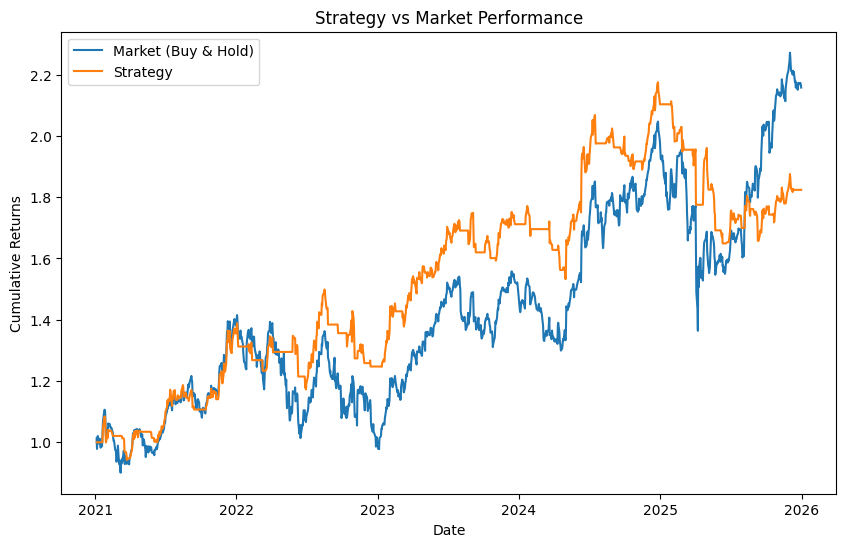

In [24]:
plt.figure(figsize=(10,6))
plt.plot(df.index, df["market_cumulative"], label="Market (Buy & Hold)")
plt.plot(df.index, df["cumulative_returns"], label="Strategy")

plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.title("Strategy vs Market Performance")
plt.legend()
plt.show()

In [25]:
print("Returns Sharpe Ratio: " + str(sharpe_ratio(df['returns'])))
print("Strategy Returns Sharpe Ratio: " + str(sharpe_ratio(df['strategy_returns'])))

Returns Sharpe Ratio: 0.6937718775264751
Strategy Returns Sharpe Ratio: 0.7584233492762715


## Momentum Strategy, Window = 20

[*********************100%***********************]  1 of 1 completed


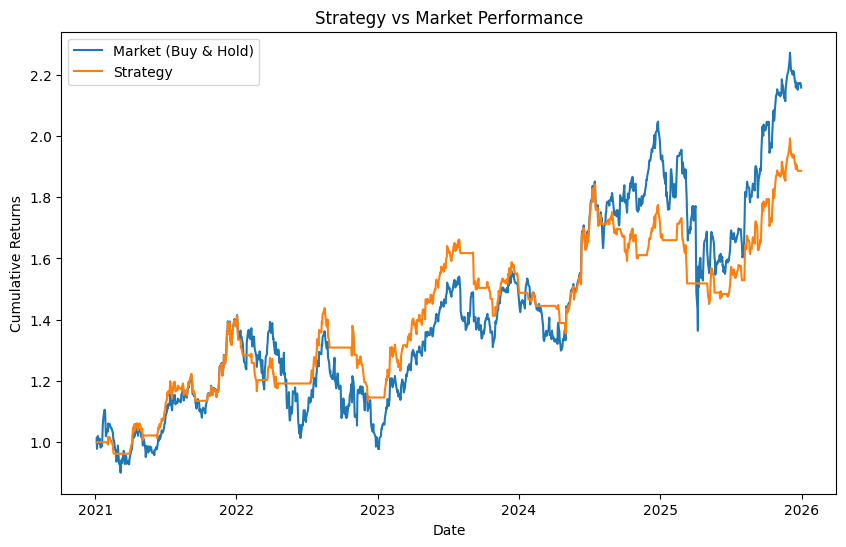

In [26]:
df = get_data('AAPL', '2021-01-01', '2026-01-01')
df = compute_returns(df)
df = moving_average(df, window = 20)
df["market_cumulative"] = (1 + df["returns"]).cumprod()
df = momentum_strategy(df, window = 20)
df = backtest(df)


plt.figure(figsize=(10,6))
plt.plot(df.index, df["market_cumulative"], label="Market (Buy & Hold)")
plt.plot(df.index, df["cumulative_returns"], label="Strategy")

plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.title("Strategy vs Market Performance")
plt.legend()
plt.show()

In [27]:
print("Returns Sharpe Ratio: " + str(sharpe_ratio(df['returns'])))
print("Strategy Returns Sharpe Ratio: " + str(sharpe_ratio(df['strategy_returns'])))

Returns Sharpe Ratio: 0.6937718775264751
Strategy Returns Sharpe Ratio: 0.8102763890581948


## Momentum Strategy, Window = 50

[*********************100%***********************]  1 of 1 completed


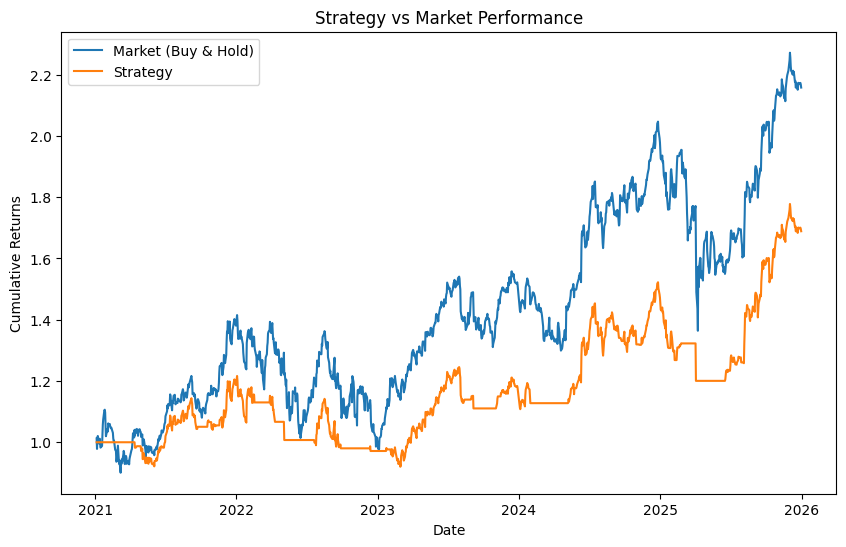

In [28]:
df = get_data('AAPL', '2021-01-01', '2026-01-01')
df = compute_returns(df)
df["market_cumulative"] = (1 + df["returns"]).cumprod()
df = momentum_strategy(df, window = 50)
df = backtest(df)


plt.figure(figsize=(10,6))
plt.plot(df.index, df["market_cumulative"], label="Market (Buy & Hold)")
plt.plot(df.index, df["cumulative_returns"], label="Strategy")

plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.title("Strategy vs Market Performance")
plt.legend()
plt.show()

In [29]:
print("Returns Sharpe Ratio: " + str(sharpe_ratio(df['returns'])))
print("Strategy Returns Sharpe Ratio: " + str(sharpe_ratio(df['strategy_returns'])))

Returns Sharpe Ratio: 0.6937718775264751
Strategy Returns Sharpe Ratio: 0.677114613522488


## Window Test

[*********************100%***********************]  1 of 1 completed


Market (Buy & Hold) Returns Sharpe Ratio: 1.2824629430750305
Best strategy window: 13
Best Sharpe ratio: 1.4595


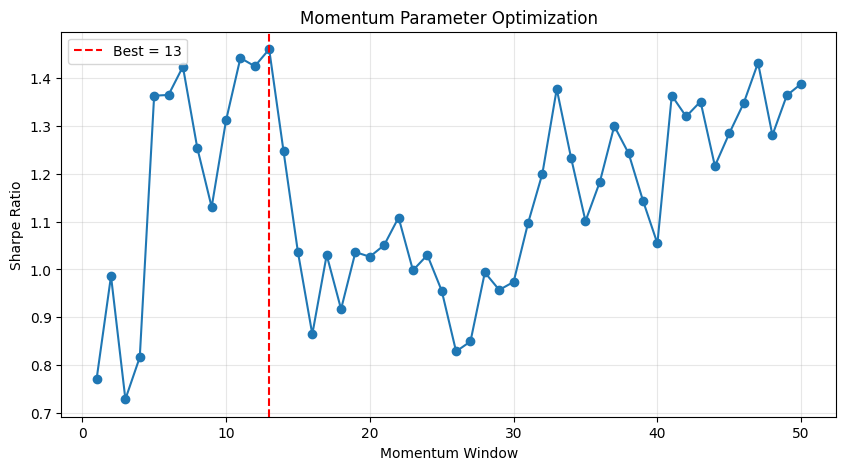

In [30]:
base_df = get_data('NVDA', '2021-01-01', '2026-01-01')
base_df = compute_returns(base_df)
base_df["market_cumulative"] = (1 + base_df["returns"]).cumprod()
bestsharpe = float('-inf')
bestsharpe_strat = None

params = []
sharpes = []

for i in range(1, 51):
    df = base_df.copy()

    df = momentum_strategy(df, i)
    df = backtest(df)

    sharpe = sharpe_ratio(df['strategy_returns'].dropna())

    params.append(i)
    sharpes.append(sharpe)

    if sharpe > bestsharpe:
        bestsharpe = sharpe
        bestsharpe_strat = i

print(f"Market (Buy & Hold) Returns Sharpe Ratio: {sharpe_ratio(base_df['returns'])}")
print(f"Best strategy window: {bestsharpe_strat}")
print(f"Best Sharpe ratio: {bestsharpe:.4f}")


plt.figure(figsize=(10, 5))
plt.plot(params, sharpes, marker='o')
plt.axvline(bestsharpe_strat,
            color='red',
            linestyle='--',
            label=f'Best = {bestsharpe_strat}')
plt.xlabel('Momentum Window')
plt.ylabel('Sharpe Ratio')
plt.title('Momentum Parameter Optimization')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

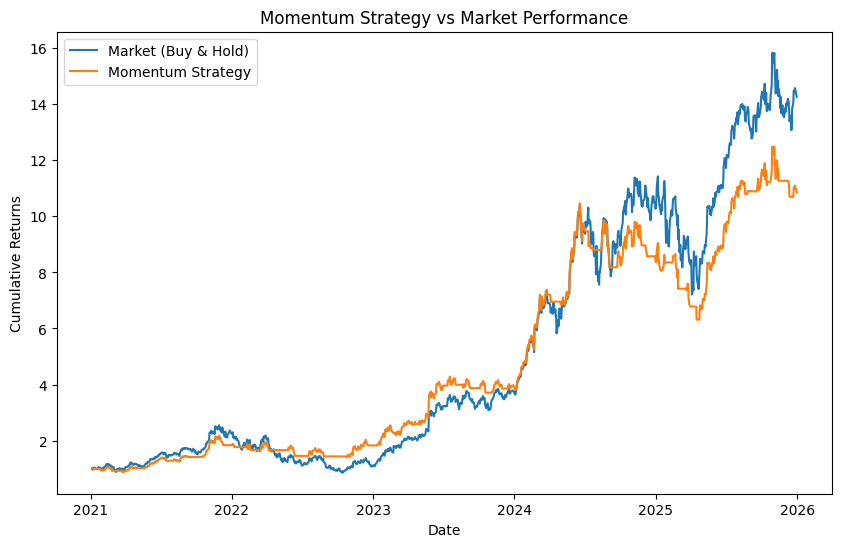

In [31]:
df = base_df.copy()
df = momentum_strategy(df, bestsharpe_strat)
#df = momentum_strategy(df, 50)
df = backtest(df)

plt.figure(figsize=(10,6))
plt.plot(df.index, df["market_cumulative"], label="Market (Buy & Hold)")
plt.plot(df.index, df["cumulative_returns"], label="Momentum Strategy")

plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.title("Momentum Strategy vs Market Performance")
plt.legend()
plt.show()